# 1D parameter estimation using maximum likelihood estimation

This example will cover:

 - Use maximum likelihood estimation to optimise kernel parameters

In [1]:
from gpvecchia.vecchia import GPtideVecchia
import numpy as np
import matplotlib.pyplot as plt

## Generate some data

Start off with the same kernel as Example 1 and generate some data.

`GPvecchia` only accepts covariance functions that use a distance matrix. 

In [2]:
from numba import njit

@njit(cache=True)
def expquad_1d(x, xpr, params):
    eta, l = params
    d = np.sum((x-xpr)**2)
    return eta**2. * np.exp(-d/(2*l*l))

In [3]:
####
# These are our kernel input parameters
noise = 0.1
η = 2
ℓ = 100
covfunc = expquad_1d

###
# Domain size parameters
dx = 200.
N = 1000
covparams = (η, ℓ)

# Input data points
xd = np.arange(0,dx*N,dx)[:,None]
xo = np.linspace(-10*dx,dx*N+dx*10,N*5)[:,None]

# A re-ordering function should always be specified - the default is no re-ordering
order_func = np.random.permutation
order_params = len(xd)

GP = GPtideVecchia(xd.copy(), xo, noise, covfunc, covparams, order_func=order_func, order_params=order_params)

# Use the .prior() method to obtain some samples
yd_obs = GP.sample_prior(samples=1, add_noise=True)

In [4]:
y_mu, y_std = GP(yd_obs.copy())

(-367.6735347069414, 5304.660932186438)

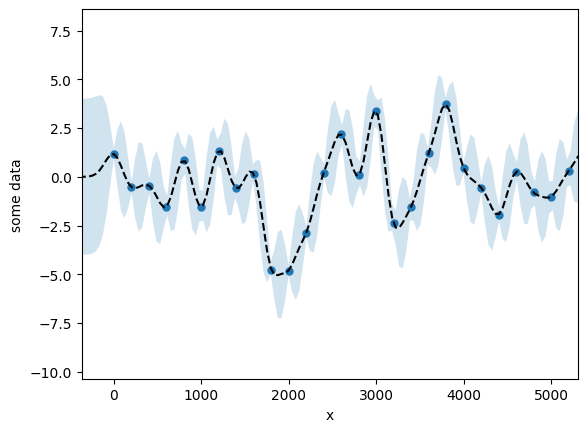

In [5]:
plt_ix = np.arange(40,180)
plt.figure()
plt.plot(xd, yd_obs,'.', markersize=10)

plt.plot(xo, y_mu,'k--')
plt.fill_between(xo.flatten(),
                 (y_mu.flatten()-2*y_std.flatten()),
                 (y_mu.flatten()+2*y_std.flatten()),
                 alpha=0.2)

plt.ylabel('some data')
plt.xlabel('x')
plt.xlim([xo[plt_ix[0]],xo[plt_ix[-1]]])

# Create a conditional sample

In [6]:
# Generate a sample
yd_prior = GP.sample_prior(ptype='output', samples=1, add_noise=False)

In [7]:
cond_samp, prior_samp = GP.conditional(yd_obs, samples=2)
cond_samp.shape

(5000, 2)

## View the conditional sample

(-367.6735347069414, 5304.660932186438)

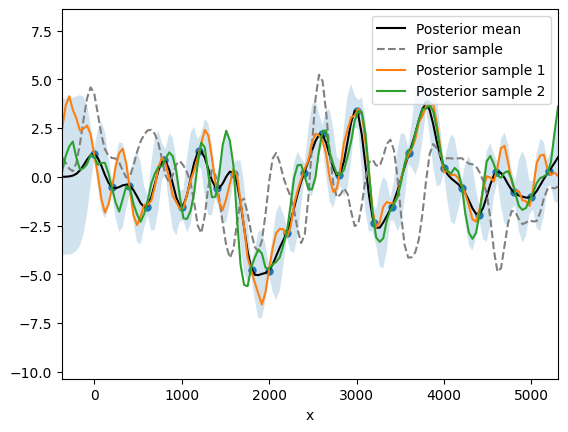

In [13]:
# plt_ix = np.arange(4500,4600)
plt.figure()
plt.plot(xd, yd_obs,'.', markersize=10)

plt.plot(xo, y_mu,'k', label='Posterior mean')
plt.fill_between(xo.flatten(),
                 (y_mu.flatten()-2*y_std.flatten()),
                 (y_mu.flatten()+2*y_std.flatten()),
                 alpha=0.2)

plt.plot(xo, np.squeeze(yd_prior), c='grey', ls='--', label='Prior sample')
plt.plot(xo, cond_samp[:,0], label='Posterior sample 1')
plt.plot(xo, cond_samp[:,1], label='Posterior sample 2')

plt.legend()
# plt.plot(xo, s_preds)

plt.xlabel('x')
plt.xlim([xo[plt_ix[0]],xo[plt_ix[-1]]])